In [1]:
import numpy as np
import matplotlib.pyplot as plt

import os
os.chdir('..')
os.getcwd()
import autograd.numpy as anp
import numpy as np
from sazz.samplers.boomerang_sampler.BoomerangSampler import BoomerangSampler
# ============================================================

def simulate_logistic_regression(n=300, p=5, seed=1):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p))
    beta_true = np.array([2.0, -1.5, 0.5, 1.0, -1.0])[:p]
    if len(beta_true) < p:
        beta_true = np.concatenate([beta_true, np.zeros(p - len(beta_true))])

    logits = X @ beta_true
    probs = 1.0 / (1.0 + np.exp(-logits))
    y = rng.binomial(1, probs, size=n)
    return X, y, beta_true


# ============================================================
# Negative log posterior targets E(beta)
# ============================================================

def E_log_reg(X, y, tau=2.0):
    """
    Bayesian logistic regression with:
        y_i | beta ~ Bernoulli(sigmoid(x_i^T beta))
        beta ~ N(0, tau^2 I)

    Returns E(beta) = negative log posterior up to additive constant.
    """
    X = anp.array(X)
    y = anp.array(y)

    def E(beta):
        eta = X @ beta
        # stable log-likelihood:
        # - sum [ y*eta - log(1+exp(eta)) ]
        nll = anp.sum(anp.logaddexp(0.0, eta) - y * eta)
        nprior = 0.5 / tau**2 * anp.sum(beta**2)
        return nll + nprior

    return E

def gradE_log_reg(X, y, tau=2.0):
    X = anp.array(X)
    y = anp.array(y)

    def gradE(beta):
        eta = X @ beta
        grad_nll = X.T @ (sigmoid(eta) - y)
        grad_prior = beta/tau**2
        return grad_nll + grad_prior
    
    return gradE

def sigmoid(x):
    return np.exp(x) / (1 + np.exp(x))

In [2]:
# Linear regression
n, p = 500, 2
X_log_reg, y_log_reg, beta_true_log_reg = simulate_logistic_regression(n=n, p=p, seed=1)
E = E_log_reg(X_log_reg, y_log_reg, tau=2.0)
gradE = gradE_log_reg(X_log_reg, y_log_reg, tau=2.0)

In [3]:
from autograd import grad
def nll_2dgaussian():
    def E(beta):
        return 0.5 * anp.dot(beta, beta)
    return E

E_gauss = nll_2dgaussian()          
gradE_gauss = grad(E_gauss)          

def nll_banana():
    def E(beta):
        # banana-shaped: twist the second coordinate
        return 0.5 * (beta[0]**2 + (beta[1] - beta[0]**2)**2)
    return E

E_banana = nll_banana()
gradE_banana = grad(E_banana)

In [4]:
N=10000
sampler_log_reg = BoomerangSampler(E=E_banana, N=N, D=p, grad_target=gradE_banana)
sampler_log_reg.preprocess(method="diagonal")

In [5]:
sampler_log_reg.sample_auto()

Boomerang time: 100%|█████████▉| 9999/10000 [00:44<00:00, 227.04iter/s, time=6302.604]

Time passed: 6302.603609530566


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def resample_pdmp_path(sampler, n_samples=4000):
    t_sk = sampler.Time
    x_sk = sampler.Position
    v_sk = sampler.Velocity

    t_grid = np.linspace(0.0, t_sk[-1], n_samples)
    idx = np.searchsorted(t_sk, t_grid, side="right") - 1
    idx = np.clip(idx, 0, len(t_sk) - 2)

    x_res = np.empty((n_samples, x_sk.shape[1]))
    for j, tg in enumerate(t_grid):
        i = idx[j]
        dt = tg - t_sk[i]
        x_res[j], _ = sampler.trajectory(dt, x_sk[i], v_sk[i])  # (t, x, v) not (x, v, t)

    return t_grid, x_res

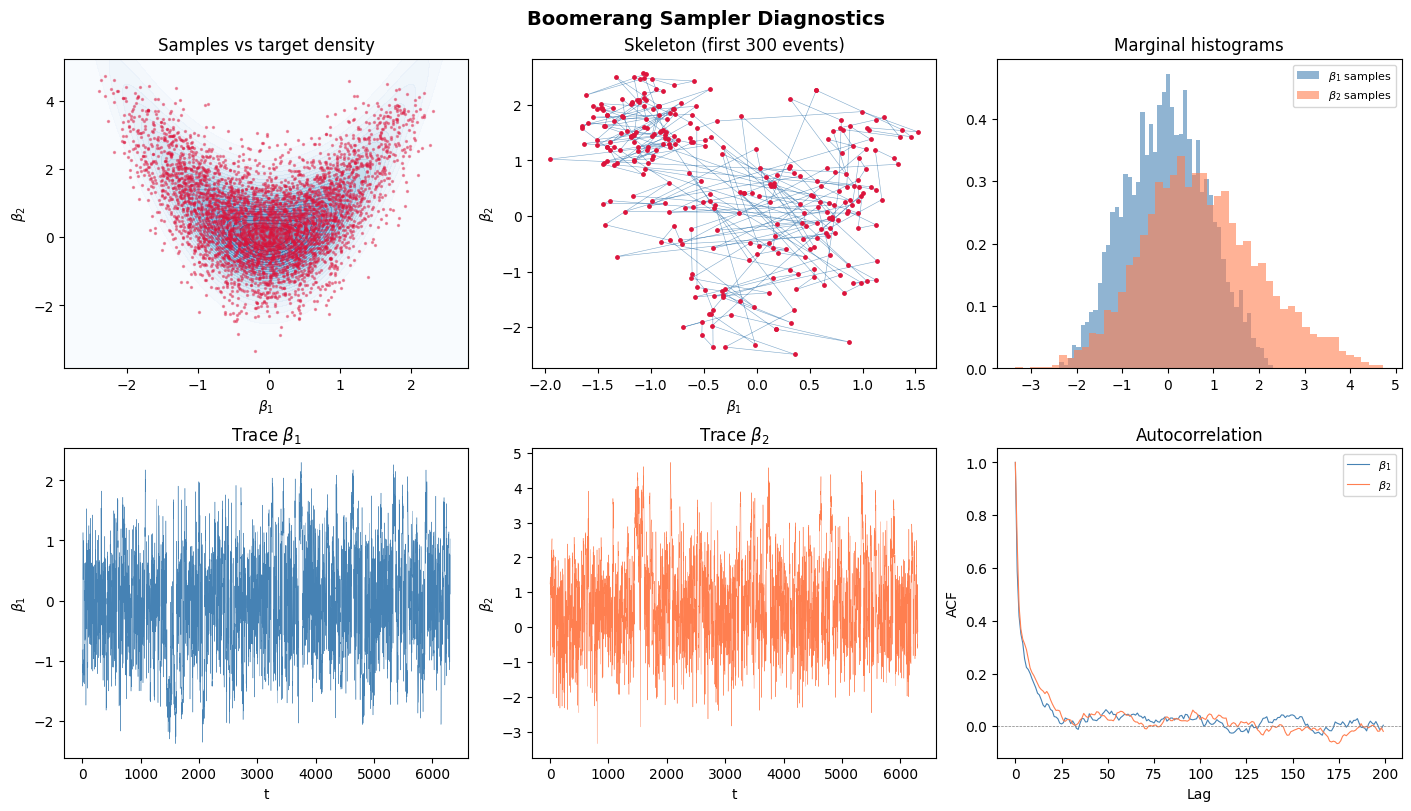

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
 
# ── resample the skeleton path ──
t, x = resample_pdmp_path(sampler_log_reg)
 
# ── ground truth contour (adjust E_fn to whatever target you used) ──
g0 = np.linspace(x[:, 0].min() - 0.5, x[:, 0].max() + 0.5, 200)
g1 = np.linspace(x[:, 1].min() - 0.5, x[:, 1].max() + 0.5, 200)
G0, G1 = np.meshgrid(g0, g1)
Z = np.zeros_like(G0)
for i in range(G0.shape[0]):
    for j in range(G0.shape[1]):
        Z[i, j] = E_banana(np.array([G0[i, j], G1[i, j]]))
 
# ── figure ──
fig = plt.figure(figsize=(14, 8), constrained_layout=True)
gs = GridSpec(2, 3, figure=fig)
 
# 1) scatter + target contour
ax1 = fig.add_subplot(gs[0, 0])
ax1.contourf(G0, G1, np.exp(-Z), levels=30, cmap="Blues", alpha=0.5)
ax1.scatter(x[:, 0], x[:, 1], s=2, c="crimson", alpha=0.4)
ax1.set_xlabel(r"$\beta_1$")
ax1.set_ylabel(r"$\beta_2$")
ax1.set_title("Samples vs target density")
 
# 2) skeleton trajectory (first 200 segments)
ax2 = fig.add_subplot(gs[0, 1])
n_show = min(300, len(sampler_log_reg.Position))
ax2.plot(sampler_log_reg.Position[:n_show, 0],
         sampler_log_reg.Position[:n_show, 1],
         lw=0.4, c="steelblue", alpha=0.7)
ax2.scatter(sampler_log_reg.Position[:n_show, 0],
            sampler_log_reg.Position[:n_show, 1],
            s=6, c="crimson", zorder=3)
ax2.set_xlabel(r"$\beta_1$")
ax2.set_ylabel(r"$\beta_2$")
ax2.set_title("Skeleton (first 300 events)")
 
# 3) marginal histograms vs analytic
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(x[:, 0], bins=50, density=True, alpha=0.6, color="steelblue", label=r"$\beta_1$ samples")
ax3.hist(x[:, 1], bins=50, density=True, alpha=0.6, color="coral", label=r"$\beta_2$ samples")
ax3.legend(fontsize=8)
ax3.set_title("Marginal histograms")
 
# 4) trace plot β₁
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(t, x[:, 0], lw=0.3, c="steelblue")
ax4.set_xlabel("t")
ax4.set_ylabel(r"$\beta_1$")
ax4.set_title(r"Trace $\beta_1$")
 
# 5) trace plot β₂
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(t, x[:, 1], lw=0.3, c="coral")
ax5.set_xlabel("t")
ax5.set_ylabel(r"$\beta_2$")
ax5.set_title(r"Trace $\beta_2$")
 
# 6) autocorrelation
ax6 = fig.add_subplot(gs[1, 2])
for dim, (col, label) in enumerate(zip(["steelblue", "coral"], [r"$\beta_1$", r"$\beta_2$"])):
    series = x[:, dim] - x[:, dim].mean()
    acf = np.correlate(series, series, mode="full")
    acf = acf[len(acf)//2:]
    acf /= acf[0]
    lags = min(200, len(acf))
    ax6.plot(range(lags), acf[:lags], lw=0.8, c=col, label=label)
ax6.axhline(0, c="grey", lw=0.5, ls="--")
ax6.set_xlabel("Lag")
ax6.set_ylabel("ACF")
ax6.set_title("Autocorrelation")
ax6.legend(fontsize=8)
 
plt.suptitle("Boomerang Sampler Diagnostics", fontsize=14, fontweight="bold")
plt.show()
 